<!-- AI-ASSISTED: Claude (claude-opus-5-5), Prompt: 'Build the Task 2 notebook: QLoRA training, merge, and evaluation against the base model', Date: 2026-10-07 -->
# Task 2: fine-tuning a small code model to write docstrings

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sathudeva7/CDAZZDEV-MLE-SATHURSAN/blob/main/task2_genai/task2_docstring_finetune.ipynb)

**Use case.** Qwen2.5-Coder-3B-Instruct is fine-tuned with QLoRA to write a Google-style
docstring for a Python function. The answer comes from the code itself, so
retrieval has nothing to add. The hard part is behaviour: one fixed layout, every
parameter and no others, `Yields` for generators, and only the exceptions the
code really raises.

This notebook is a thin driver. The logic lives in `task2_genai/` and carries offline
tests in `tests/test_task2_data.py`. Each section matches one rubric row, and every
number is printed by a code cell, so no figure in the text can drift from the run.

| Rubric row | Section | Where the logic lives |
|---|---|---|
| 2A Use case quality | 2A.1 | this notebook, `task2_genai/docstrings.py` |
| 2A Dataset size, teacher prompt | 2A.2, 2A.3 | `task2_genai/generate_data.py`, `prompts.py` |
| 2A Dataset diversity | 2A.4 | `task2_genai/recipes.py`, `metrics.py` |
| 2A Format and split | 2A.3, 2A.5 | `task2_genai/dataset.py` |
| 2B QLoRA implementation | 2B.2 | `task2_genai/finetune.py` |
| 2B Hyperparameter justification | 2B.1 | `finetune.HYPERPARAMETERS` |
| 2B Loss monitoring | 2B.3, 2B.4 | `finetune.build_trainer`, `epoch_losses` |
| 2B Model saved | 2B.5 | `finetune.merge_adapter` (`merge_and_unload()`) |
| 2C ROUGE-L comparison | 2C.1, 2C.3 | `metrics.rouge_l` |
| 2C Additional metric | 2C.4, 2C.5 | BERTScore; `metrics.structure_labels` |
| 2C Hallucination rate | 2C.6 | manual labels in this notebook |
| 2C Qualitative analysis | 2C.7 | this notebook |

**Models.** Teacher: OpenAI's GPT-6.1 Sol wrote the functions and their docstrings
(`task2_genai/generate_data.py`, run once locally; the data is committed). It is a paid
API, a deliberate exception to the free-tier setup (`docs/adr/0002-paid-teacher-for-task2.md`),
and a different model family from the student. Student: `Qwen/Qwen2.5-Coder-3B-Instruct`,
trained on Colab's free T4 GPU.

**To run it yourself:** Runtime → Change runtime type → T4 GPU. Add a Hugging Face
token with write access as `HF_TOKEN` under Colab's Secrets (the key icon) to publish
the merged model; without it the model is saved to the runtime's disk only. Then
Runtime → Run all, about an hour.

## Setup

In [15]:
# AI-ASSISTED: Claude (claude-opus-5-5), Prompt: 'Build the Task 2 notebook: QLoRA training, merge, and evaluation against the base model', Date: 2026-10-07
import subprocess
import sys
import time
from pathlib import Path

RUN_STARTED = time.perf_counter()
REPO_URL = "https://github.com/sathudeva7/CDAZZDEV-MLE-SATHURSAN"
REPO_REF = "main"  # the branch or tag the Colab run clones
HF_REPO_NAME = "qwen2.5-coder-3b-docstrings"

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    ROOT = Path("/content") / REPO_URL.rsplit("/", 1)[-1]
    if ROOT.exists():
        subprocess.run(["git", "-C", str(ROOT), "pull", "--quiet"], check=True)
    else:
        subprocess.run(["git", "clone", "--quiet", "--depth", "1", "--branch", REPO_REF, REPO_URL, str(ROOT)], check=True)
    subprocess.run([sys.executable, "-m", "pip", "install", "--quiet", "-r", str(ROOT / "task2_genai" / "requirements.txt")], check=True)
    RUN_DIR = Path("/content/t2_run")  # checkpoints and the 6 GB merged model stay out of the repo
else:
    ROOT = Path.cwd().parent if Path.cwd().name == "task2_genai" else Path.cwd()
    from dotenv import load_dotenv
    load_dotenv(ROOT / ".env")
    RUN_DIR = ROOT / ".t2_run"
sys.path.insert(0, str(ROOT))

import bitsandbytes
import peft
import torch
import transformers

from common.llm import enable_console_logging
from common.llm_config import secret
from task2_genai.finetune import BASE_MODEL, SEED

enable_console_logging()
transformers.set_seed(SEED)
EVAL_DIR = ROOT / "task2_genai" / "evaluation"
EVAL_DIR.mkdir(exist_ok=True)
RUN_DIR.mkdir(parents=True, exist_ok=True)

commit = subprocess.run(["git", "-C", str(ROOT), "rev-parse", "--short", "HEAD"], capture_output=True, text=True, check=False).stdout.strip()
print(f"Running in {'Colab' if IN_COLAB else 'a local kernel'}, repo at {commit or 'unknown commit'}")
print(f"torch {torch.__version__}, transformers {transformers.__version__}, peft {peft.__version__}, bitsandbytes {bitsandbytes.__version__}")
assert torch.cuda.is_available(), "No GPU: Runtime -> Change runtime type -> T4 GPU"
gpu = torch.cuda.get_device_properties(0)
print(f"GPU: {gpu.name}, {gpu.total_memory / 1e9:.1f} GB")
print(f"Student: {BASE_MODEL}")
print(f"  {'✓' if secret('HF_TOKEN') else '✗'} HF_TOKEN")  # presence only, never the value

Running in Colab, repo at db86638
torch 2.11.0+cu130, transformers 4.57.6, peft 0.21.1, bitsandbytes 0.50.2
GPU: Tesla T4, 15.6 GB
Student: Qwen/Qwen2.5-Coder-3B-Instruct
  ✓ HF_TOKEN


## 2A.1 Problem statement

**Input.** One Python function (5 to 40 lines) with no docstring: a plain function, a
method (with `self`), a generator or an `async def`.

**Output.** Only the docstring text, in this fixed Google-style layout:

```
Apply a percentage discount to a price, optionally capped.

Args:
    price: Original price.
    pct: Discount percentage, from 0 to 100.
    cap: Largest discount allowed; no cap when None.

Returns:
    The price after the discount.

Raises:
    ValueError: If pct is outside 0-100.
```

**What counts as correct.** `task2_genai/docstrings.py` reads the function with Python's
`ast` module and checks the docstring against it:

| Label | Meaning |
|---|---|
| correct | Every real parameter documented (never `self`/`cls`) and no others; `Returns` or `Yields` matches the code; `Raises` lists exactly the exceptions in the function's own `raise` statements; a true one-line summary. |
| partially correct | Nothing invented, but something missing: a parameter, a section, or a vague summary. |
| hallucinated | Mentions a parameter, exception, return value or yield the code does not have. Invented beats missing. |

The `ast` check covers parameters and sections automatically. Whether the summary is
true is judged by hand in 2C.6.

**Why fine-tuning and not RAG.** Everything the answer needs is in the input, so
there is nothing to retrieve. What a small model gets wrong is behaviour: it mixes
styles, documents `self`, writes `Returns` for generators and lists exceptions it
assumes might happen. That is what fine-tuning changes. A tuned 3B model also runs
locally, so private code never leaves the machine, at a fraction of a large model's cost.

## 2A.2 Teacher model and its prompts

Each example takes two teacher calls (`task2_genai/generate_data.py`):

1. **Functions.** One call per recipe cell (topic × kind) writes two new functions at
   each of three levels. Fresh code means the student cannot have memorised the
   answers during pretraining.
2. **Docstring.** A second call sees **only the code**, exactly as the student will, and
   fills the docstring as fields that our code renders into one fixed layout. The
   label therefore describes the code as written, not what the teacher meant it to do.

The full prompts follow (the brief asks for them), then the teacher's call log.

In [16]:
# AI-ASSISTED: Claude (claude-opus-5-5), Prompt: 'Build the Task 2 notebook: QLoRA training, merge, and evaluation against the base model', Date: 2026-10-07
import pandas as pd

from task2_genai.prompts import STUDENT_SYSTEM, TEACHER_DOCSTRING, TEACHER_FUNCTIONS

for title, text in [
    ("Teacher call 1, system", TEACHER_FUNCTIONS.system),
    ("Teacher call 1, user template", TEACHER_FUNCTIONS.user),
    ("Teacher call 2, system", TEACHER_DOCSTRING.system),
    ("Teacher call 2, user template", TEACHER_DOCSTRING.user),
    ("Student system prompt (base and fine-tuned alike)", STUDENT_SYSTEM),
]:
    print(f"===== {title} =====\n{text}\n")

calls = pd.read_json(ROOT / "task2_genai" / "logs" / "teacher_calls.jsonl", lines=True)
print("Teacher call log (task2_genai/logs/teacher_calls.jsonl):")
print(calls.groupby(["prompt", "model", "outcome"]).agg(
    calls=("ts", "size"), prompt_tokens=("prompt_tokens", "sum"), completion_tokens=("completion_tokens", "sum")
).to_string())

===== Teacher call 1, system =====
You write realistic Python functions for a dataset that teaches a small model to document code. Each request names a topic, a kind of function and how many functions to write at each difficulty level.

Rules:
- Each function does a different, realistic job within the topic; vary names, parameters and logic so no two are near copies.
- Use type hints on parameters and return values.
- No docstring, no comments, no decorators, no imports. Standard-library modules and names (json, re, math, asyncio, datetime, Path, Decimal, defaultdict ...) may be used as if already imported.
- Exactly one top-level def per function. Helper logic goes inline, not in nested defs.
- When a function raises, use a specific built-in exception (ValueError, KeyError, TypeError, FileNotFoundError, TimeoutError, ...) with a message.
- Code must be valid Python 3.11 and correct.

===== Teacher call 1, user template =====
Topic: {topic} ({topic_hint})
Kind: {kind_hint}
Write {per_l

## 2A.3 Dataset size, filtering and split

Every function the teacher wrote is validated (exactly one `def`, the requested kind,
5 to 40 lines, no docstring, a name not seen before). Every docstring is labelled by
the `ast` check, and only `correct` ones are kept, so a teacher mistake never becomes
a training target. The kept examples are split 80/10/10, stratified by kind
(`dataset.split`, seed 42).

In [17]:
# AI-ASSISTED: Claude (claude-opus-5-5), Prompt: 'Build the Task 2 notebook: QLoRA training, merge, and evaluation against the base model', Date: 2026-10-07
import re
from collections import Counter

from task2_genai.dataset import DATA_DIR, SPLITS, read_jsonl

functions = read_jsonl(DATA_DIR / "functions.jsonl")
rejected = read_jsonl(DATA_DIR / "rejected.jsonl")
labels = read_jsonl(DATA_DIR / "labels.jsonl")
splits = {name: read_jsonl(DATA_DIR / f"{name}.jsonl") for name in SPLITS}
kept = sum(len(rows) for rows in splits.values())
label_counts = Counter(row["label"] for row in labels)

print(pd.DataFrame({
    "step": ["Functions written by the teacher (call 1)", "Passed validation",
             "Docstrings written by the teacher (call 2)", "Docstrings passing the ast check (kept)"],
    "examples": [len(functions) + len(rejected), len(functions), len(labels), label_counts["correct"]],
}).to_string(index=False))

reasons = Counter(re.sub(r" '.*'|: .*|\d+", "", row["reason"]).strip() for row in rejected)
print("\nRejected functions by reason:", dict(reasons))
print("Docstring labels from the ast check:", dict(label_counts))
for row in [r for r in labels if r["label"] != "correct"][:3]:
    print(f"  dropped {row['id']}: {row['label']}, missing {row['missing']}, invented {row['invented']}")

sizes = pd.DataFrame({"split": SPLITS, "examples": [len(splits[s]) for s in SPLITS]})
sizes["share"] = (sizes.examples / kept).map("{:.0%}".format)
print(f"\n{kept} examples kept, split as:")
print(sizes.to_string(index=False))
assert kept == label_counts["correct"]

                                      step  examples
 Functions written by the teacher (call 1)       288
                         Passed validation       264
Docstrings written by the teacher (call 2)       264
   Docstrings passing the ast check (kept)       264

Rejected functions by reason: {'lines, outside -': 1, 'duplicate function name': 23}
Docstring labels from the ast check: {'correct': 264}

264 examples kept, split as:
split  examples share
train       212   80%
  val        26   10%
 test        26   10%


## 2A.4 Diversity

Variety is built in by the recipe grid (`task2_genai/recipes.py`): 12 topics × 4 kinds ×
3 levels. This section measures it: prompt lengths in the student's own tokens, the grid
coverage, keyword frequencies, and the most similar pair of functions in the whole set.

       code_tokens  docstring_tokens  total_tokens
count        264.0             264.0         264.0
mean         202.0             120.0         576.0
std          124.0              52.0         173.0
min           35.0              35.0         326.0
25%           82.0              70.0         402.0
50%          188.0             119.0         558.0
75%          302.0             162.0         722.0
max          497.0             246.0         984.0


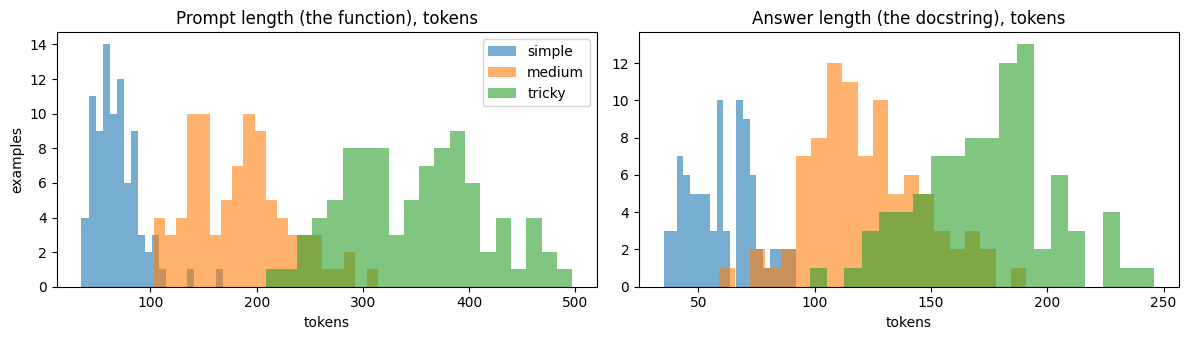

In [18]:
# AI-ASSISTED: Claude (claude-opus-5-5), Prompt: 'Build the Task 2 notebook: QLoRA training, merge, and evaluation against the base model', Date: 2026-10-07
import matplotlib.pyplot as plt

from task2_genai.finetune import load_tokenizer

tokenizer = load_tokenizer()
records = [dict(r, split=name) for name in SPLITS for r in splits[name]]


def n_tokens(text: str) -> int:
    return len(tokenizer(text, add_special_tokens=False)["input_ids"])


stats = pd.DataFrame([{
    "id": r["id"], "topic": r["topic"], "kind": r["kind"], "level": r["level"], "split": r["split"],
    "code_tokens": n_tokens(r["messages"][1]["content"]),
    "docstring_tokens": n_tokens(r["messages"][2]["content"]),
    "total_tokens": n_tokens(tokenizer.apply_chat_template(r["messages"], tokenize=False)),
} for r in records])
print(stats[["code_tokens", "docstring_tokens", "total_tokens"]].describe().round(0).to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
for level in ["simple", "medium", "tricky"]:
    subset = stats[stats.level == level]
    axes[0].hist(subset.code_tokens, bins=20, alpha=0.6, label=level)
    axes[1].hist(subset.docstring_tokens, bins=20, alpha=0.6, label=level)
axes[0].set(title="Prompt length (the function), tokens", xlabel="tokens", ylabel="examples")
axes[1].set(title="Answer length (the docstring), tokens", xlabel="tokens")
axes[0].legend()
plt.tight_layout()
plt.show()

In [19]:
# AI-ASSISTED: Claude (claude-opus-5-5), Prompt: 'Build the Task 2 notebook: QLoRA training, merge, and evaluation against the base model', Date: 2026-10-07
from task2_genai import metrics

print("Examples per topic and kind:")
print(pd.crosstab(stats.topic, stats.kind, margins=True).to_string())
print("\nExamples per level:", stats.level.value_counts().to_dict())

codes = [r["messages"][1]["content"] for r in records]
ids = [r["id"] for r in records]
print("\nTop 20 words in function names:", metrics.name_words(codes).most_common(20))
print("Standard-library modules called (functions using each):", metrics.modules_used(codes).most_common(15))

pairs = metrics.near_duplicates(ids, codes)
print(f"\nMost similar pairs (Jaccard similarity of character 5-grams; {metrics.NEAR_DUPLICATE_JACCARD} would mean near copies):")
for a, b, sim in pairs:
    print(f"  {sim:.2f}  {a}  vs  {b}")
print("No near-duplicates in the dataset" if pairs[0][2] < metrics.NEAR_DUPLICATE_JACCARD else "Near-duplicates found")

Examples per topic and kind:
kind           async  function  generator  method  All
topic                                                 
caching            6         6          6       6   24
collections        6         6          6       6   24
data_cleaning      5         6          5       3   19
datetime           6         6          6       6   24
files              5         6          6       5   22
finance            6         6          6       5   23
geometry           4         6          6       6   22
http               6         6          6       5   23
simulation         5         6          5       6   22
statistics         2         6          6       2   16
text               6         4          5       6   21
validation         6         6          6       6   24
All               63        70         69      62  264

Examples per level: {'tricky': 90, 'medium': 88, 'simple': 86}

Top 20 words in function names: [('iter', 23), ('records', 11), ('text', 11), ('m

## 2A.5 JSONL format and chat template

Each line of `task2_genai/data/{train,val,test}.jsonl` holds the recipe fields and a
`messages` list of system, user and assistant turns. At training time the tokenizer's
own chat template renders it into Qwen's format. One training example, exactly as the
model sees it:

In [20]:
# AI-ASSISTED: Claude (claude-opus-5-5), Prompt: 'Build the Task 2 notebook: QLoRA training, merge, and evaluation against the base model', Date: 2026-10-07
example = splits["train"][0]
print({k: v for k, v in example.items() if k != "messages"})
print(tokenizer.apply_chat_template(example["messages"], tokenize=False))

{'id': 'datetime-async-medium-02', 'topic': 'datetime', 'kind': 'async', 'level': 'medium'}
<|im_start|>system
You write docstrings for Python functions. The user sends one function. Reply with only the docstring text: no quotes, no code fences, no code.

Docstring rules (Google style):
- First line: a one-line summary in the imperative mood ("Return ...", "Parse ..."), ending with a period.
- Keep it short. Add one paragraph after the summary only when a caller would be surprised without it, at most two sentences.
- Args: every parameter in signature order, one per line as "    name: description", at most 15 words each. Never document self or cls. Write *args and **kwargs without the stars.
- Returns: what the function returns. Leave the section out when it returns nothing, and for generators.
- Yields: what each iteration yields. Only for generators (functions that use yield).
- Raises: only exceptions raised by a raise statement in this function's own body, one per line as "    Exce

## 2B.1 Hyperparameters

Every setting is in `task2_genai/finetune.py` with the reason it was chosen; the table
below is printed from that code. The two lengths are then checked against the data.

In [21]:
# AI-ASSISTED: Claude (claude-opus-5-5), Prompt: 'Build the Task 2 notebook: QLoRA training, merge, and evaluation against the base model', Date: 2026-10-07
from task2_genai.finetune import HYPERPARAMETERS, hp

table = pd.DataFrame([{"parameter": name, "value": str(h.value), "reason": h.reason} for name, h in HYPERPARAMETERS.items()])
with pd.option_context("display.max_colwidth", None):
    display(table)

longest = int(stats.total_tokens.max())
longest_answer = int(stats.docstring_tokens.max())
print(f"Longest example: {longest} tokens, max_seq_length {hp('max_seq_length')}: nothing is truncated")
print(f"Longest reference docstring: {longest_answer} tokens, max_new_tokens {hp('max_new_tokens')}")
assert longest <= hp("max_seq_length") and longest_answer < hp("max_new_tokens")

,parameter,value,reason
0,load_in_4bit / bnb_4bit_quant_type,"4-bit, nf4","QLoRA's NF4 type is built for normally distributed weights, so it loses less than plain 4-bit; it brings the 3B model to about 2 GB, leaving the T4's 15 GB for activations."
1,bnb_4bit_use_double_quant,True,"Quantizes the quantization constants too, saving about 0.4 bits per weight at no accuracy cost (QLoRA paper)."
2,bnb_4bit_compute_dtype,float16,"The T4 has no bfloat16 support, so matrix multiplies run in float16, which it accelerates."
3,lora_r,16,"Learning one fixed docstring layout and a few rules is a narrow skill; rank 16 on every linear layer gives about 30M trainable weights, enough for that, while rank 64 would mostly memorise ~210 examples."
4,lora_alpha,32,"alpha = 2 x r keeps the update scale (alpha / r = 2) fixed if r is changed, the usual pairing in PEFT examples; with alpha = r the adapter moves half as far per step at the same learning rate."
5,lora_dropout,0.1,The QLoRA paper used 0.1 for models up to 13B; with this little data some regularisation is worth it.
6,target_modules,"['q_proj', 'k_proj', 'v_proj', 'o_proj', 'gate_proj', 'up_proj', 'down_proj']",The QLoRA paper found LoRA on every linear layer is needed to match full fine-tuning; attention-only adapters underperform. These are all of Qwen2's linear projections.
7,learning_rate,0.0002,"The QLoRA paper's rate for 7B-13B models. With only ~45 optimizer steps in total, a smaller rate would barely move the adapter."
8,lr_scheduler_type,cosine,"Decays smoothly towards zero, so the last epoch takes small steps; on a tiny dataset that protects the validation loss from late overfitting."
9,warmup_ratio,0.05,The first few steps run at a reduced rate while Adam's moment estimates are still noisy; 5% of ~45 steps is 3 steps.


Longest example: 984 tokens, max_seq_length 1536: nothing is truncated
Longest reference docstring: 246 tokens, max_new_tokens 384


## 2C.1 Baseline answers, before any training

The base model answers the test set first, with the same system prompt the fine-tuned
model gets and greedy decoding. Generating these now means only one model is on the
T4 at a time.

In [22]:
# AI-ASSISTED: Claude (claude-opus-5-5), Prompt: 'Build the Task 2 notebook: QLoRA training, merge, and evaluation against the base model', Date: 2026-10-07
from task2_genai.finetune import free_gpu, generate, load_fp16

test = splits["test"]
started = time.perf_counter()
base_model = load_fp16(BASE_MODEL)
base_answers = generate(base_model, tokenizer, test)
del base_model
free_gpu()
print(f"{len(base_answers)} baseline answers in {time.perf_counter() - started:.0f} s. First one ({test[0]['id']}):\n")
print(base_answers[0])

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

26 baseline answers in 32 s. First one (geometry-async-simple-02):

Calculate the center of a bounding box defined by its minimum and maximum coordinates.

Args:
    bounds: A tuple containing four floats representing the bounding box's minimum and maximum x and y coordinates.

Returns:
    A tuple containing the center x and y coordinates of the bounding box.


## 2B.2 QLoRA model

The student is loaded in 4-bit NF4 with double quantization, prepared for k-bit training
(`prepare_model_for_kbit_training`), and given LoRA adapters on every linear layer
(`finetune.load_quantized_model`). Only the adapters train.

In [23]:
# AI-ASSISTED: Claude (claude-opus-5-5), Prompt: 'Build the Task 2 notebook: QLoRA training, merge, and evaluation against the base model', Date: 2026-10-07
from task2_genai.finetune import load_quantized_model

model = load_quantized_model()
quant = model.config.quantization_config
print(f"4-bit: {quant.load_in_4bit}, type: {quant.bnb_4bit_quant_type}, double quant: {quant.bnb_4bit_use_double_quant}, "
      f"compute dtype: {quant.bnb_4bit_compute_dtype}")
for name, module in model.named_modules():
    if name.endswith("layers.0.self_attn.q_proj"):
        print(f"{name}: {type(module).__name__} wrapping {type(module.base_layer).__name__}")
model.print_trainable_parameters()
print(f"GPU memory in use: {torch.cuda.memory_allocated() / 1e9:.1f} GB")

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

4-bit: True, type: nf4, double quant: True, compute dtype: torch.float16
base_model.model.model.layers.0.self_attn.q_proj: Linear4bit wrapping Linear4bit
trainable params: 29,933,568 || all params: 3,115,872,256 || trainable%: 0.9607
GPU memory in use: 4.1 GB


## 2B.3 Training

Each example is tokenized with the prompt masked out of the labels, so the loss covers
only the docstring and its end token (`finetune.tokenize_record`). The Trainer evaluates
on the validation split after every epoch and keeps the best epoch.

In [24]:
# AI-ASSISTED: Claude (claude-opus-5-5), Prompt: 'Build the Task 2 notebook: QLoRA training, merge, and evaluation against the base model', Date: 2026-10-07
from task2_genai.finetune import IGNORE_INDEX, build_trainer, tokenize_record

tokenizer.padding_side = "right"
train_rows = [tokenize_record(r, tokenizer) for r in splits["train"]]
val_rows = [tokenize_record(r, tokenizer) for r in splits["val"]]
answer_tokens = sum(sum(label != IGNORE_INDEX for label in row["labels"]) for row in train_rows)
all_tokens = sum(len(row["input_ids"]) for row in train_rows)
print(f"{len(train_rows)} train and {len(val_rows)} validation examples; "
      f"the loss covers {answer_tokens} of {all_tokens} training tokens ({answer_tokens / all_tokens:.0%})")

trainer = build_trainer(model, tokenizer, train_rows, val_rows, RUN_DIR / "checkpoints")
started = time.perf_counter()
trainer.train()
print(f"Trained in {(time.perf_counter() - started) / 60:.1f} min; peak GPU memory {torch.cuda.max_memory_allocated() / 1e9:.1f} GB")

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


212 train and 26 validation examples; the loss covers 25644 of 121762 training tokens (21%)


Epoch,Training Loss,Validation Loss
1,1.254700,0.989224
2,0.888500,0.903338
3,0.736900,0.894415


Trained in 16.0 min; peak GPU memory 14.3 GB


## 2B.4 Training and validation loss per epoch

 epoch  train_loss  val_loss
     1      1.2547    0.9892
     2      0.8885    0.9033
     3      0.7369    0.8944

Validation loss decreases every epoch: True
Best validation loss 0.8944, kept from /content/t2_run/checkpoints/checkpoint-42


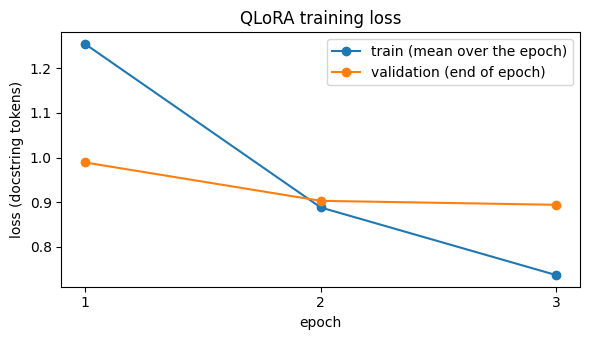

1106

In [25]:
# AI-ASSISTED: Claude (claude-opus-5-5), Prompt: 'Build the Task 2 notebook: QLoRA training, merge, and evaluation against the base model', Date: 2026-10-07
import json

from task2_genai.finetune import epoch_losses

losses = pd.DataFrame(epoch_losses(trainer.state.log_history))
print(losses.round(4).to_string(index=False))
val_decreasing = bool((losses.val_loss.diff().dropna() < 0).all())
print(f"\nValidation loss decreases every epoch: {val_decreasing}")
print(f"Best validation loss {trainer.state.best_metric:.4f}, kept from {trainer.state.best_model_checkpoint}")

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(losses.epoch, losses.train_loss, marker="o", label="train (mean over the epoch)")
ax.plot(losses.epoch, losses.val_loss, marker="o", label="validation (end of epoch)")
ax.set(xlabel="epoch", ylabel="loss (docstring tokens)", xticks=losses.epoch, title="QLoRA training loss")
ax.legend()
plt.tight_layout()
fig.savefig(EVAL_DIR / "loss_per_epoch.png", dpi=120)
plt.show()
(EVAL_DIR / "loss_history.json").write_text(json.dumps(trainer.state.log_history, indent=1))

## 2B.5 Merge and publish

The best adapter is saved, then folded into the base model with `merge_and_unload()`.
The merge uses the float16 base, not the 4-bit training copy, so no quantization error
is baked into the saved weights. The merged model is pushed to the Hugging Face Hub
with a model card and the base model's licence.

In [27]:
# AI-ASSISTED: Claude (claude-opus-5-5), Prompt: 'Fix the torchao ImportError in the Task 2 merge step', Date: 2026-10-07
# Colab ships torchao 0.10, which peft rejects when loading an adapter onto a float16 model.
# Nothing in this notebook uses torchao, so remove it instead of upgrading it.
import importlib

subprocess.run([sys.executable, "-m", "pip", "uninstall", "-y", "-q", "torchao"], check=True)
importlib.invalidate_caches()
print("torchao removed")


torchao removed


In [30]:
# AI-ASSISTED: Claude (claude-opus-5-5), Prompt: 'Build the Task 2 notebook: QLoRA training, merge, and evaluation against the base model', Date: 2026-10-07
# AI-ASSISTED: Claude (claude-opus-5-5), Prompt: 'Fix the torchao ImportError in the Task 2 merge step', Date: 2026-10-07
import shutil

from task2_genai.finetune import merge_adapter

ADAPTER_DIR = RUN_DIR / "adapter"
MERGED_DIR = RUN_DIR / "merged"
if "trainer" in globals():  # the cell can be re-run after the adapter is saved
    trainer.model.save_pretrained(ADAPTER_DIR)  # the best epoch, reloaded by load_best_model_at_end
    del model, trainer
    free_gpu()
print("Adapter files:", sorted(p.name for p in ADAPTER_DIR.iterdir()))


merged = merge_adapter(ADAPTER_DIR)
merged.save_pretrained(MERGED_DIR)
tokenizer.save_pretrained(MERGED_DIR)
size_gb = sum(f.stat().st_size for f in MERGED_DIR.glob("*")) / 1e9
print(f"Merged model saved to {MERGED_DIR} ({size_gb:.1f} GB)")

MODEL_URL = None
hf_token = secret("HF_TOKEN")
if hf_token:
    from huggingface_hub import HfApi, hf_hub_download

    api = HfApi(token=hf_token)
    repo_id = f"{api.whoami()['name']}/{HF_REPO_NAME}"
    shutil.copy(hf_hub_download(BASE_MODEL, "LICENSE"), MERGED_DIR / "LICENSE")
    (MERGED_DIR / "README.md").write_text(
        "---\nbase_model: " + BASE_MODEL + "\nlicense: other\nlicense_name: qwen-research\n"
        "license_link: LICENSE\nlibrary_name: transformers\ntags: [qlora, docstrings, code]\n---\n\n"
        "# Qwen2.5-Coder-3B-Instruct, fine-tuned to write Google-style docstrings\n\n"
        f"QLoRA fine-tune of `{BASE_MODEL}` (adapters merged with `merge_and_unload()`), trained on "
        f"{len(splits['train'])} teacher-written Python functions with ast-checked docstrings. "
        "Send one function as the user message with the system prompt from "
        "[task2_genai/prompts.py](" + REPO_URL + "/blob/main/task2_genai/prompts.py); "
        "the reply is the docstring text. Training and evaluation: " + REPO_URL + "/tree/main/task2_genai\n"
    )
    api.create_repo(repo_id, exist_ok=True, private=False)
    api.upload_folder(folder_path=str(MERGED_DIR), repo_id=repo_id, commit_message="Merged QLoRA fine-tune for docstrings")
    MODEL_URL = f"https://huggingface.co/{repo_id}"
    print("Published:", MODEL_URL)
else:
    print("HF_TOKEN is not set, so the merged model is only on this runtime's disk:", MERGED_DIR)

Adapter files: ['README.md', 'adapter_config.json', 'adapter_model.safetensors']


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Merged model saved to /content/t2_run/merged (6.2 GB)


LICENSE: 0.00B [00:00, ?B/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...run/merged/tokenizer.json: 100%|##########| 11.4MB / 11.4MB            

  ...0002-of-00002.safetensors:   0%|          |  524kB / 1.21GB            

  ...0001-of-00002.safetensors:   0%|          | 15.9MB / 4.96GB            

Published: https://huggingface.co/sathudeva7/qwen2.5-coder-3b-docstrings


<!-- AI-ASSISTED: Claude (claude-opus-5-5), Prompt: 'Write 2B.6 and 2C.7 from the submission run's outputs', Date: 2026-10-07 -->
## 2B.6 Out-of-memory and other errors in this run

The run met two errors, both after training. Each is fixed in a cell kept in the notebook, so a
fresh top-to-bottom run passes too.

**1. `ImportError` at the merge.** The error read: *"Found an incompatible version of torchao.
Found version 0.10.0, but only versions above 0.16.0 are supported"*.
- **Cause:** Colab preinstalls torchao 0.10. peft checks for torchao when it loads an adapter
  onto a float16 model (`PeftModel.from_pretrained`) and rejects old versions. Training never
  reached that check, because there the adapter sits on 4-bit layers.
- **Fix:** nothing here uses torchao, so the cell above the merge uninstalls it rather than
  upgrading it. Upgrading would risk a torch version clash.
- **Follow-up:** the merge cell now saves the adapter only while `trainer` exists, so it can be
  re-run without retraining.

**2. CUDA out of memory before the fine-tuned answers.** The error read: *"Tried to allocate
112.00 MiB … this process has 14.52 GiB memory in use"* on the 14.5 GB T4.
- **Cause:** the merged model needs about 6 GB. The failed merge attempt had loaded a float16
  base model (another 6 GB), and Python kept it alive through the saved traceback
  (`sys.last_traceback`). `del` and `torch.cuda.empty_cache()` cannot free memory that is
  still referenced.
- **Fix** (the cell above 2C.2):
  - clear the `sys.last_*` references and collect garbage, which dropped memory from 14.2 GB
    to 2.5 GB
  - reload the merged model from disk (8.7 GB in use)
  - generate with batch 4 instead of 8
- **Lesson:** a cell that fails while holding GPU tensors leaks them. In a pipeline, run train,
  merge and evaluate as separate processes, so each stage starts with an empty GPU.

**Training memory.** Training peaked at 14.3 GB of 14.5 GB (2B.3), at batch 4 with gradient
checkpointing and a longest example of 984 tokens. That is at the edge. Had it run out, the next
step would be batch 2 with gradient accumulation 8, which keeps the effective batch at 16 and the
optimizer steps unchanged.

## 2C.2 Fine-tuned answers

The merged model answers the same test set with the same system prompt and decoding
as the baseline in 2C.1.

In [37]:
# AI-ASSISTED: Claude (claude-opus-5-5), Prompt: 'Fix the CUDA out-of-memory error before the fine-tuned answers', Date: 2026-10-07
# OOM fix: the failed merge attempt left a float16 base model alive through the saved
# traceback (sys.last_traceback), so two 6 GB models shared the 14.5 GB T4.
# Drop the traceback references, free the GPU, and reload the merged model from disk.
import gc

from task2_genai.finetune import load_fp16

for name in ("last_type", "last_value", "last_traceback", "last_exc"):
    setattr(sys, name, None)
merged = None
gc.collect()
torch.cuda.empty_cache()
print(f"GPU memory in use after cleanup: {torch.cuda.memory_allocated() / 1e9:.1f} GB")

merged = load_fp16(MERGED_DIR)
print(f"GPU memory with the merged model loaded: {torch.cuda.memory_allocated() / 1e9:.1f} GB")


GPU memory in use after cleanup: 2.5 GB


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

GPU memory with the merged model loaded: 8.7 GB


In [38]:
# AI-ASSISTED: Claude (claude-opus-5-5), Prompt: 'Build the Task 2 notebook: QLoRA training, merge, and evaluation against the base model', Date: 2026-10-07
started = time.perf_counter()
ft_answers = generate(merged, tokenizer, test, batch_size=4)

del merged
free_gpu()
print(f"{len(ft_answers)} fine-tuned answers in {time.perf_counter() - started:.0f} s. First one ({test[0]['id']}):\n")
print(ft_answers[0])

26 fine-tuned answers in 78 s. First one (geometry-async-simple-02):

Return the bounding box's midpoint, sleeping zero time before computing it.

Args:
    bounds: Bounding box coordinates as (left, bottom, right, top).

Returns:
    A tuple containing the midpoint's x and y coordinates.

Raises:
    ValueError: If any minimum exceeds its corresponding maximum.


## 2C.3 ROUGE-L on the held-out test set

ROUGE-L F1 against the teacher's checked docstring (Google's `rouge-score`, Porter
stemming), both models on the identical test set. Code fences and wrapping quotes are
stripped from both models' answers alike (`docstrings.clean_output`).

In [39]:
# AI-ASSISTED: Claude (claude-opus-5-5), Prompt: 'Build the Task 2 notebook: QLoRA training, merge, and evaluation against the base model', Date: 2026-10-07
references = [r["messages"][2]["content"] for r in test]
scores = pd.DataFrame({
    "id": [r["id"] for r in test], "kind": [r["kind"] for r in test], "level": [r["level"] for r in test],
    "base_rougeL": metrics.rouge_l(base_answers, references),
    "ft_rougeL": metrics.rouge_l(ft_answers, references),
})
print(f"Test set: {len(test)} functions, identical for both models\n")
print(pd.DataFrame({
    "model": ["Base (system prompt, no fine-tuning)", "Fine-tuned (QLoRA, merged)"],
    "ROUGE-L F1 mean": [scores.base_rougeL.mean(), scores.ft_rougeL.mean()],
    "median": [scores.base_rougeL.median(), scores.ft_rougeL.median()],
    "min": [scores.base_rougeL.min(), scores.ft_rougeL.min()],
}).round(3).to_string(index=False))
print("\nMean ROUGE-L F1 by kind:")
print(scores.groupby("kind")[["base_rougeL", "ft_rougeL"]].mean().round(3).to_string())

Test set: 26 functions, identical for both models

                               model  ROUGE-L F1 mean  median   min
Base (system prompt, no fine-tuning)            0.242   0.236 0.069
          Fine-tuned (QLoRA, merged)            0.540   0.552 0.400

Mean ROUGE-L F1 by kind:
           base_rougeL  ft_rougeL
kind                             
async            0.238      0.562
function         0.298      0.529
generator        0.211      0.547
method           0.218      0.523


## 2C.4 BERTScore F1

BERTScore compares meaning rather than exact words (`roberta-large`, the package's default
for English), so a correct docstring worded differently from the reference is not
punished as hard as under ROUGE-L. Scores are rescaled with the package's baseline, which
spreads them over a readable range.

In [40]:
# AI-ASSISTED: Claude (claude-opus-5-5), Prompt: 'Build the Task 2 notebook: QLoRA training, merge, and evaluation against the base model', Date: 2026-10-07
from bert_score import score as bert_score

from task2_genai.docstrings import clean_output

for column, answers in [("base_bertscore", base_answers), ("ft_bertscore", ft_answers)]:
    _, _, f1 = bert_score([clean_output(a) for a in answers], references, lang="en", rescale_with_baseline=True, verbose=False)
    scores[column] = f1.tolist()
print(pd.DataFrame({
    "model": ["Base (system prompt, no fine-tuning)", "Fine-tuned (QLoRA, merged)"],
    "BERTScore F1 mean": [scores.base_bertscore.mean(), scores.ft_bertscore.mean()],
    "median": [scores.base_bertscore.median(), scores.ft_bertscore.median()],
}).round(3).to_string(index=False))

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


                               model  BERTScore F1 mean  median
Base (system prompt, no fine-tuning)              0.035   0.021
          Fine-tuned (QLoRA, merged)              0.594   0.580


## 2C.5 Structure check on every test answer

The same `ast` check that filtered the training data labels every answer from both
models. It cannot judge whether the summary is true (2C.6 does that by hand), but it
catches every invented parameter, exception or section without anyone reading the answer.

In [41]:
# AI-ASSISTED: Claude (claude-opus-5-5), Prompt: 'Build the Task 2 notebook: QLoRA training, merge, and evaluation against the base model', Date: 2026-10-07
codes_test = [r["messages"][1]["content"] for r in test]
base_checks = metrics.structure_labels(codes_test, base_answers)
ft_checks = metrics.structure_labels(codes_test, ft_answers)
scores["base_check"] = [c["label"] for c in base_checks]
scores["ft_check"] = [c["label"] for c in ft_checks]

order = ["correct", "partial", "hallucinated", "unparseable"]
check_table = pd.DataFrame({
    "Base": scores.base_check.value_counts().reindex(order, fill_value=0),
    "Fine-tuned": scores.ft_check.value_counts().reindex(order, fill_value=0),
})
print(check_table.to_string())
for name, column in [("Base", "base_check"), ("Fine-tuned", "ft_check")]:
    share = (scores[column] == "hallucinated").mean()
    print(f"{name}: {share:.0%} of answers invent a parameter, exception or section")
print("\nWhat the base model got wrong most often:",
      Counter(item.split(" ")[0] + " " + kind for c in base_checks for kind in ("missing", "invented") for item in c[kind]).most_common(5))

              Base  Fine-tuned
correct          0          22
partial         26           3
hallucinated     0           1
unparseable      0           0
Base: 0% of answers invent a parameter, exception or section
Fine-tuned: 4% of answers invent a parameter, exception or section

What the base model got wrong most often: [('arg missing', 82), ('raises missing', 30), ('Returns missing', 18), ('Yields missing', 7)]


## 2C.6 Manual review and hallucination rate

Twelve test answers from the fine-tuned model, picked at random with the notebook's seed
before reading any answers. Each is labelled **correct**, **partial** or **hallucinated**
using the definitions in 2A.1, including whether the summary is true, which the `ast`
check cannot see. The checker's label is shown as a hint only.

The labels were made by reading each answer against its code, with Claude as a second
reviewer (cited in the cell). Every label was checked against the code by the candidate.

In [42]:
# AI-ASSISTED: Claude (claude-opus-5-5), Prompt: 'Build the Task 2 notebook: QLoRA training, merge, and evaluation against the base model', Date: 2026-10-07
import random

REVIEW_COUNT = 12
review_ids = [test[i]["id"] for i in sorted(random.Random(SEED).sample(range(len(test)), REVIEW_COUNT))]
by_id = {r["id"]: i for i, r in enumerate(test)}
for rid in review_ids:
    i = by_id[rid]
    check = ft_checks[i]
    print(f"{'=' * 30} {rid} {'=' * 30}\n{codes_test[i]}\n{'-' * 20} fine-tuned answer {'-' * 20}\n{ft_answers[i]}")
    print(f"{'-' * 20} checker: {check['label']}, missing {check['missing']}, invented {check['invented']}\n")

============================== geometry-async-simple-02 ==============================
async def bounding_box_center(bounds: tuple[float, float, float, float]) -> tuple[float, float]:
    left, bottom, right, top = bounds
    if left > right or bottom > top:
        raise ValueError("Bounding box minimums must not exceed maximums")
    await asyncio.sleep(0)
    center_x = left / 2 + right / 2
    center_y = bottom / 2 + top / 2
    return center_x, center_y
-------------------- fine-tuned answer --------------------
Return the bounding box's midpoint, sleeping zero time before computing it.

Args:
    bounds: Bounding box coordinates as (left, bottom, right, top).

Returns:
    A tuple containing the midpoint's x and y coordinates.

Raises:
    ValueError: If any minimum exceeds its corresponding maximum.
-------------------- checker: correct, missing [], invented []

============================== http-async-simple-02 ==============================
async def inspect_headers(client: A

In [45]:
# AI-ASSISTED: Claude (claude-opus-5-5), Prompt: 'Build the Task 2 notebook: QLoRA training, merge, and evaluation against the base model', Date: 2026-10-07
# AI-ASSISTED: Claude (claude-opus-5-5), Prompt: 'can u please check these outputs and can u label them (second reviewer; labels confirmed by the candidate)', Date: 2026-10-07
# Labelled after reading each answer against its code (Claude as second reviewer): (label, note), label one of correct / partial / hallucinated.
MANUAL_LABELS: dict[str, tuple[str, str]] = {
    "geometry-async-simple-02": ("correct", "all sections and the summary match the code"),
    "http-async-simple-02": ("correct", "accurate; raise_for_status is not a raise statement here"),
    "finance-async-tricky-02": ("hallucinated", "invents 'rounding down to zero for zero interest'; calls the nominal rate 'effective'"),
    "datetime-async-simple-01": ("correct", "all sections and the summary match the code"),
    "files-function-tricky-01": ("hallucinated", "says ValueError when the workspace is not a directory; the code raises NotADirectoryError"),
    "caching-function-medium-01": ("partial", "omits that expired entries are deleted from the cache"),
    "validation-generator-simple-02": ("correct", "accurate, including nonfinite readings"),
    "validation-generator-tricky-02": ("correct", "accurate; 'text inputs' slightly undersells non-string handling"),
    "files-method-medium-02": ("correct", "accurate; count of changed options matches the code"),
    "validation-method-simple-01": ("hallucinated", "documents a max_length parameter the method does not have"),
    "datetime-method-simple-02": ("partial", "'rounded up to zero' garbles the clamp at zero"),
    "caching-method-tricky-02": ("hallucinated", "TypeError condition reversed: the code rejects booleans"),
}

unlabelled = [rid for rid in review_ids if rid not in MANUAL_LABELS]
if unlabelled:
    print("Label these first:", unlabelled)
else:
    review = pd.DataFrame([{"id": rid, "label": MANUAL_LABELS[rid][0], "note": MANUAL_LABELS[rid][1],
                            "checker": ft_checks[by_id[rid]]["label"]} for rid in review_ids])
    with pd.option_context("display.max_colwidth", None):
        display(review)
    counts = review.label.value_counts()
    hallucinated = int(counts.get("hallucinated", 0))
    print(dict(counts))
    print(f"Hallucination rate: {hallucinated / len(review):.0%} ({hallucinated} of {len(review)} reviewed answers)")

,id,label,note,checker
0,geometry-async-simple-02,correct,all sections and the summary match the code,correct
1,http-async-simple-02,correct,accurate; raise_for_status is not a raise statement here,correct
2,finance-async-tricky-02,hallucinated,invents 'rounding down to zero for zero interest'; calls the nominal rate 'effective',correct
3,datetime-async-simple-01,correct,all sections and the summary match the code,correct
4,files-function-tricky-01,hallucinated,says ValueError when the workspace is not a directory; the code raises NotADirectoryError,partial
5,caching-function-medium-01,partial,omits that expired entries are deleted from the cache,correct
6,validation-generator-simple-02,correct,"accurate, including nonfinite readings",correct
7,validation-generator-tricky-02,correct,accurate; 'text inputs' slightly undersells non-string handling,correct
8,files-method-medium-02,correct,accurate; count of changed options matches the code,correct
9,validation-method-simple-01,hallucinated,documents a max_length parameter the method does not have,hallucinated


{'correct': np.int64(6), 'hallucinated': np.int64(4), 'partial': np.int64(2)}
Hallucination rate: 33% (4 of 12 reviewed answers)


<!-- AI-ASSISTED: Claude (claude-opus-5-5), Prompt: 'Write 2B.6 and 2C.7 from the submission run's outputs', Date: 2026-10-07 -->
## 2C.7 Qualitative analysis

**Where fine-tuning helped.** The gain is in structure, and it is large.
- **The base model was not wrong, it was incomplete.** With the same system prompt it mostly
  wrote a prose summary. Only 1 of its 26 answers had an `Args:` section, and none had `Raises:`,
  although 22 of the 26 test functions raise. None of the 7 generators got `Yields:`. The `ast`
  check therefore found 82 missing parameters, 30 missing exceptions, 18 missing `Returns` and
  7 missing `Yields`, and labelled 0 of 26 answers correct (2C.5).
- **After fine-tuning, 22 of 26 answers pass that check.**
  - Every generator gets `Yields`.
  - No method documents `self`.
  - Async functions are described by what they await, for example "sleeping zero time
    before computing it" for the `await asyncio.sleep(0)` in `geometry-async-simple-02`.
  - In that same function, the base model skipped the `ValueError` for an inverted box;
    the tuned model documents it with the right condition.
- **The scores move with the structure.** ROUGE-L F1 rises from 0.24 to 0.54 and BERTScore F1
  from 0.04 to 0.59. The gain holds for every kind of function; generators, for example, go
  from 0.21 to 0.55 on ROUGE-L.
- **The loss confirms a real fit, not memorisation.** Validation loss fell every epoch
  (0.989, 0.903, 0.894). The flattening at epoch 3 suggests more epochs would not help on 212
  examples.

**What still fails, and what would fix it.** The manual review found 4 of 12 answers
hallucinated (33%), while the `ast` check flagged only 1. Fine-tuning moved the errors from
structure into prose:
- **Wrong exception names:** `files-function-tricky-01` puts "the workspace is not a
  directory" under `ValueError`, but the code raises `NotADirectoryError`.
- **Reversed conditions:** `caching-method-tricky-02` implies booleans are accepted as a
  capacity, but the code rejects them.
- **Invented behaviour in the optional paragraph:** `finance-async-tricky-02` claims payments
  are "rounding down to zero for zero interest".
- **A parameter taken from what email validators usually have:** `validation-method-simple-01`
  documents a `max_length` parameter that does not exist.

The two partial answers omit or garble a side effect: a deleted cache entry, and a clamp at zero.

These errors cluster in tricky functions with many `raise` conditions, and in the free-text
paragraph after the summary. Four changes would address them:
1. **More, targeted data.** Scale the grid from 212 to about 1,000 training examples. Weight it
   towards tricky functions with several exception types and side effects, plus "near-miss"
   functions that look like common APIs but differ from them.
2. **Stricter labels.** Extend the `ast` check to pair each `raise` with its `if` condition,
   and use the result to filter the training data. Use the same check to build preference
   pairs (a correct docstring against a hallucinated one) for a DPO pass.
3. **Less free text.** Make the extra paragraph rarer in the training targets, since that is
   where invention concentrates.
4. **A guardrail at inference.** Run the `ast` check on every answer and regenerate when it
   fails. That alone would have caught the `max_length` case.

One limit of the method itself: the references are one teacher's wording, checked by `ast` but
not reviewed by a person. So ROUGE-L partly rewards copying the teacher's style, and the teacher's
prose may carry the same kinds of errors.

## Run outputs

In [46]:
# AI-ASSISTED: Claude (claude-opus-5-5), Prompt: 'Build the Task 2 notebook: QLoRA training, merge, and evaluation against the base model', Date: 2026-10-07
summary = {
    "student": BASE_MODEL,
    "model_url": MODEL_URL,
    "split_sizes": {s: len(splits[s]) for s in SPLITS},
    "loss_per_epoch": losses.to_dict(orient="records"),
    "rougeL_f1_mean": {"base": scores.base_rougeL.mean(), "fine_tuned": scores.ft_rougeL.mean()},
    "bertscore_f1_mean": {"base": scores.base_bertscore.mean(), "fine_tuned": scores.ft_bertscore.mean()},
    "structure_check": check_table.to_dict(),
    "manual_review": MANUAL_LABELS,
    "runtime_min": round((time.perf_counter() - RUN_STARTED) / 60, 1),
}
(EVAL_DIR / "results.json").write_text(json.dumps(summary, indent=1))
with (EVAL_DIR / "predictions.jsonl").open("w") as fh:
    for i, r in enumerate(test):
        fh.write(json.dumps({"id": r["id"], "code": codes_test[i], "reference": references[i],
                             "base": base_answers[i], "fine_tuned": ft_answers[i],
                             **{k: scores.iloc[i][k] for k in ["base_rougeL", "ft_rougeL", "base_bertscore", "ft_bertscore", "base_check", "ft_check"]}}) + "\n")
print(json.dumps({k: v for k, v in summary.items() if k != "manual_review"}, indent=1, default=str))

if IN_COLAB:
    shutil.make_archive("/content/task2_run_outputs", "zip", EVAL_DIR)
    from google.colab import files
    files.download("/content/task2_run_outputs.zip")

{
 "student": "Qwen/Qwen2.5-Coder-3B-Instruct",
 "model_url": "https://huggingface.co/sathudeva7/qwen2.5-coder-3b-docstrings",
 "split_sizes": {
  "train": 212,
  "val": 26,
  "test": 26
 },
 "loss_per_epoch": [
  {
   "epoch": 1,
   "train_loss": 1.2547,
   "val_loss": 0.9892237782478333
  },
  {
   "epoch": 2,
   "train_loss": 0.8885,
   "val_loss": 0.9033381938934326
  },
  {
   "epoch": 3,
   "train_loss": 0.7369,
   "val_loss": 0.8944147825241089
  }
 ],
 "rougeL_f1_mean": {
  "base": 0.24227073892110282,
  "fine_tuned": 0.5401593480852401
 },
 "bertscore_f1_mean": {
  "base": 0.03525183930133398,
  "fine_tuned": 0.5942225353075907
 },
 "structure_check": {
  "Base": {
   "correct": 0,
   "partial": 26,
   "hallucinated": 0,
   "unparseable": 0
  },
  "Fine-tuned": {
   "correct": 22,
   "partial": 3,
   "hallucinated": 1,
   "unparseable": 0
  }
 },
 "runtime_min": 65.7
}


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>